In [1]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy
from tqdm import tqdm
import time

import torch
import matplotlib.pyplot as plt

## Check mnfinder_clean_data cleaned the overlap or not? 

In [3]:
path = '/scr/yren/datasets/mnfinder_clean_data/validation/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]
mic_files = [file for file in files if file.endswith('.phenotype_outlines.png')]
nuc_files = [file.replace('.phenotype_outlines.png', '.nuclei-clean.tif') for file in mic_files]
for m,n in zip(mic_files, nuc_files):
    mic_masks = skimage.io.imread(path + m) # here is for mnfinder data
    nuc_masks = skimage.io.imread(path + n)
    
    # print(mic_masks.shape)
    # print(nuc_masks.shape)
    mask = np.mean(mic_masks, axis=2) > 0
    edge = skimage.filters.sobel(mask) > 0
    full_mic = mask + edge
    overlap = np.logical_and(full_mic, nuc_masks)
    print(np.unique(overlap))
    # print(np.unique(nuc_masks))

[False]
[False]
[False]


# Filter BBBC039 with micronuclei annotation

In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

- create histogram of input images, check the size distribution!
  

(520, 696, 4)


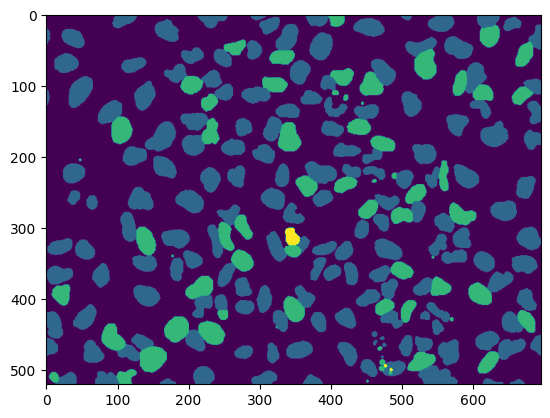

In [31]:
mask_path = '/scr/yren/BBBC039/masks/'
masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
im = skimage.io.imread(mask_path + 'IXMtest_K12_s7_w12A7857A5-3C92-4A08-8E81-2CA8A99F67AE.png')
print(im.shape)
plt.imshow(im[:,:,0])
im = im[:,:,0]

16


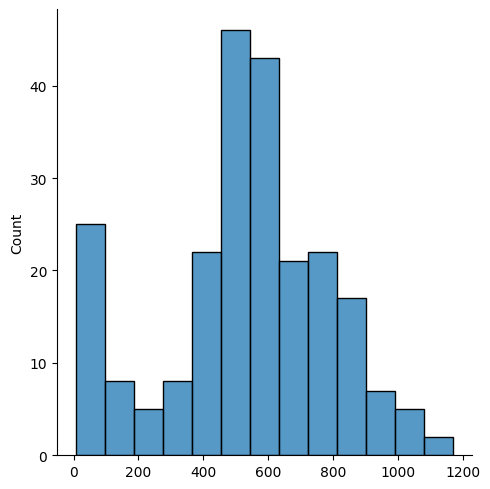

In [32]:
areas = []
labels = skimage.morphology.label(im)
for i in range(1, len(np.unique(labels))):
    a = np.sum(labels == i)
    if a == 99:
        print(i)
    areas.append(int(a))
sns.displot(areas)

In [39]:
print(sorted(areas))

[12, 16, 19, 21, 21, 26, 31, 87, 99, 143, 150, 161, 178, 210, 268, 294, 312, 337, 372, 392, 409, 409, 413, 431, 435, 441, 459, 462, 469, 475, 481, 484, 501, 501, 505, 507, 511, 518, 523, 526, 535, 535, 549, 552, 552, 557, 561, 564, 566, 571, 572, 576, 581, 583, 584, 586, 592, 595, 596, 602, 607, 607, 631, 637, 637, 638, 644, 645, 646, 651, 653, 654, 655, 656, 656, 671, 671, 672, 679, 679, 691, 695, 708, 709, 710, 715, 717, 723, 728, 739, 744, 744, 744, 753, 769, 772, 792, 792, 795, 797, 799, 814, 818, 821, 822, 837, 841, 859, 863, 866, 879, 882, 883, 896, 923, 927, 954, 963, 984, 1043, 1160, 1204, 1212, 1326, 1398, 1418, 1560, 1700]


In [15]:
print(im.shape)

(520, 696)


324 551
[[  0 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]]


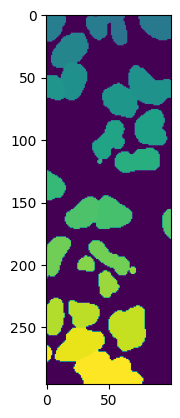

In [33]:
# area of 99 simes to be nuclei instead of micronuclei, below 50 has micronuclei makes more sense.
ys, xs = np.where(labels == 127)
y,x = int(np.mean(ys)), int(np.mean(xs))
print(y,x)
print(labels[y-5:y+5,x-5:x+5])
plt.imshow(labels[y-100:,x-50:x+50])

## Iterate through all images, define which should be discarded. Seperate BBBC039 nuclei and micronuclei in ground truth, change the suffix too!

- Example

In [97]:
im = skimage.io.imread(mask_path + 'IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.png')
im = np.mean(im, axis=2) # dont use this
np.unique(im)

array([63.75, 64.  , 64.25, 64.5 ])

In [12]:
mask_path = '/scr/yren/BBBC039/masks/'
masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
im = skimage.io.imread(mask_path + 'IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.png')

print(im.shape)
# plt.imshow(im[:,:,0])
im = im[:,:,0] # dont use np.mean, background values will be averaged which results in value > 0, cant seperate.
# im = np.mean(im, axis=2)

MICRON_AREA_THRESHOLD = 50
labels = skimage.morphology.label(im)
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD: # 50
        micron_labels.append(i)
        
print(micron_labels)
micro_mask = np.zeros_like(im)
for i in micron_labels:
    micro_mask += (labels == i)
nuclei_mask = (labels > 0) ^ (micro_mask > 0) # xor only works on binary case

(520, 696, 4)
[15, 39, 45, 98, 101, 102, 120]


In [13]:
np.unique(im)

array([0, 1, 2, 3], dtype=uint8)

In [14]:
np.unique(nuclei_mask)

array([False,  True])

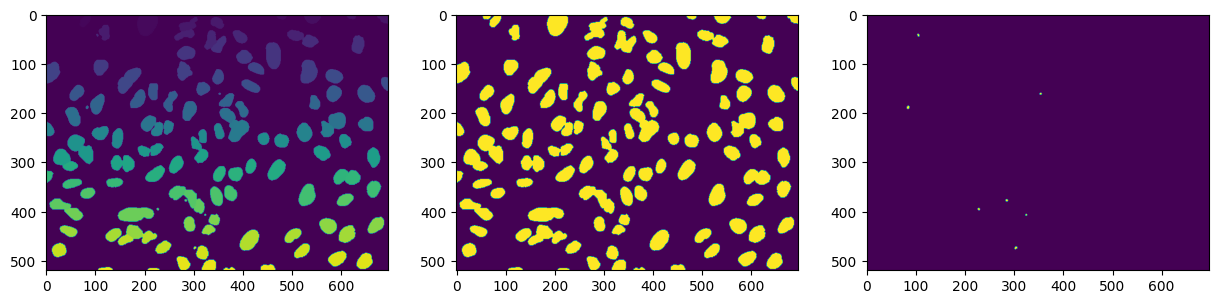

In [15]:
fig, axs = plt.subplots(1,3, figsize=(15,15))
axs[0].imshow(labels)
axs[1].imshow(nuclei_mask)
axs[2].imshow(micro_mask) 

- save nuclei mask as nuclei-clean.tif, and micronuclei as phenotype_outlines.png, no channel information (grayscale), remember to rescale

[False  True]


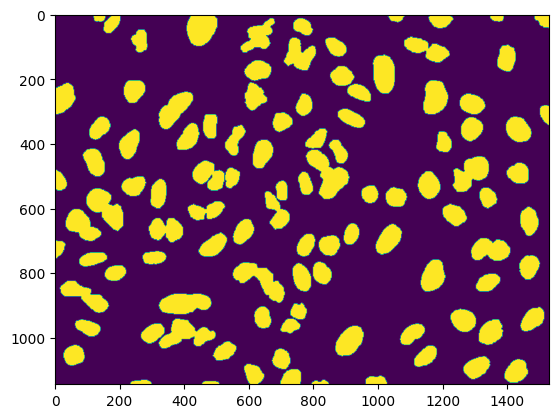

In [16]:
nuc = skimage.transform.rescale(nuclei_mask, 2.2)
print(np.unique(nuc))
plt.imshow(nuc)

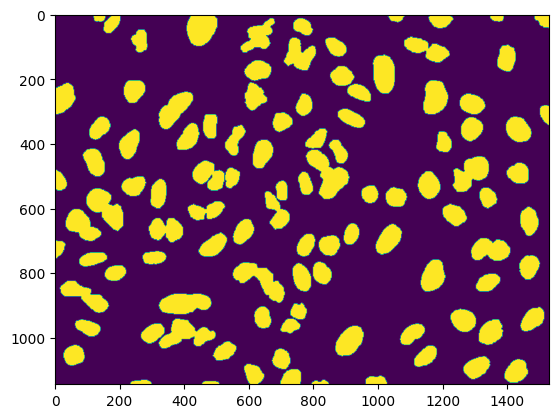

In [17]:
im2 = skimage.io.imread('/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.nuclei.tif')
plt.imshow(im2)

In [4]:
scale = round((14/4.25)/(20/13.1), 1)
scale

2.2

In [66]:
mat = np.random.randint(0, 2, size=(10, 10))
mat2 = skimage.transform.rescale(mat, 2.2)
print(np.unique(mat))
print(np.unique(mat2))

[0 1]
[0.00000000e+00 1.79206971e-21 1.79206971e-21 2.68810456e-21
 2.68810456e-21 3.58413941e-21 3.58413941e-21 3.58413941e-21
 3.58413941e-21 4.48017427e-21 4.48017427e-21 4.48017427e-21
 5.37620912e-21 6.27224397e-21 6.27224397e-21 7.16827883e-21
 7.16827883e-21 7.16827883e-21 8.06431368e-21 8.06431368e-21
 8.06431368e-21 8.06431368e-21 8.96034853e-21 8.96034853e-21
 9.85638339e-21 9.85638339e-21 1.07524182e-20 1.07524182e-20
 1.07524182e-20 1.07524182e-20 1.07524182e-20 1.34405228e-20
 1.43365577e-20 1.43365577e-20 1.43365577e-20 1.61286274e-20
 1.61286274e-20 1.61286274e-20 1.61286274e-20 1.79206971e-20
 1.79206971e-20 1.88167319e-20 1.97127668e-20 1.97127668e-20
 2.15048365e-20 2.15048365e-20 2.15048365e-20 2.15048365e-20
 2.15048365e-20 2.15048365e-20 2.24008713e-20 2.41929410e-20
 2.41929410e-20 2.50889759e-20 2.50889759e-20 2.59850107e-20
 2.68810456e-20 2.68810456e-20 2.68810456e-20 2.68810456e-20
 2.68810456e-20 2.77770805e-20 2.86731153e-20 2.86731153e-20
 2.86731153e-20 2.

In [ ]:
print(im.shape)
im2 = skimage.transform.rescale(im, scale=scale)
print(im2.shape)

(520, 696)
(520, 696, 4)
(1144, 1531)


# Process and Rescale BBBC039 images, save as labeled matrices

In [3]:
MICRON_AREA_THRESHOLD = 50 # reasonable threshold based
scale = round((14/4.25)/(20/13.1), 1) # 2.2

mask_path = '/scr/yren/BBBC039/masks/'
image_path = '/scr/yren/BBBC039/images/'
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
image_save_path = '/scr/yren/BBBC039_cleaned_rescaled/images/'

masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
masks = [mask for mask in masks if mask.endswith('.png')]
# print(len(masks))

# min_areas = []
for mask_name in tqdm(masks):
    mask = skimage.io.imread(mask_path + mask_name)
    mask = mask[:,:,0]
    areas = []
    labels = skimage.morphology.label(mask)
    micron_labels = []
    for i in range(1, len(np.unique(labels))):
        a = np.sum(labels == i)
        if a < MICRON_AREA_THRESHOLD:
            micron_labels.append(i)
        areas.append(int(a))
        
    if (len(areas) > 0) and (len(micron_labels) > 4): # there are few images that only has background... and at least 5 objects of interest
        if min(areas) <= MICRON_AREA_THRESHOLD: # has micronuclei
            # seperate nuclei & micronuclei channel
            micro_mask = np.zeros_like(mask)
            for j in micron_labels:
                micro_mask += (labels == j)
            nuclei_mask = (labels > 0) ^ (micro_mask > 0)
            
            # rescale the input, nuclei mask, micronuclei mask
            imid = mask_name.split('.')[0]
            im = skimage.io.imread(image_path + imid + '.tif')
            im = skimage.transform.rescale(im, scale=scale)
            # print(im.shape)
            # print(nuclei_mask.shape)
            # print(micro_mask.shape)
            
            # if input is boolean, then output is also boolean.
            nuclei_mask = skimage.transform.rescale(nuclei_mask, scale=scale)
            micro_mask = skimage.transform.rescale(micro_mask > 0, scale=scale)
        
            # convert to labeled matrices
            micro_mask = micro_mask > 0
            micro_labels = skimage.morphology.label(micro_mask)
            micro_labels = np.asarray(micro_labels, dtype='uint16') # 2^16: 65,535, labels rarely go beyond this value, and it only takes 2 bytes, uint32 takes 4 bytes, save space!
            
            nuclei_mask = nuclei_mask > 0
            nuclei_labels = skimage.morphology.label(nuclei_mask)
            nuclei_labels = np.asarray(nuclei_labels, dtype='uint16')
            
            # save all of the three and add suffix
            skimage.io.imsave(image_save_path + imid + '.phenotype.tif', im)
            skimage.io.imsave(mask_save_path + imid + '.nuclei.tif', nuclei_labels)
            skimage.io.imsave(mask_save_path + imid + '.phenotype_outlines.png', micro_labels)


  0%|          | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_4180907/1491787318.py:59: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/images/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype.tif is a low contrast image
  skimage.io.imsave(image_save_path + imid + '.phenotype.tif', im)
/tmp/ipykernel_4180907/1491787318.py:60: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif is a low contrast image
  skimage.io.imsave(mask_save_path + imid + '.nuclei.tif', nuclei_labels)
/tmp/ipykernel_4180907/1491787318.py:61: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(mask_save_path + imid + '.phenotype_outlines.png', micro_labels)
  0%|          | 1/200 [00:00<00:38,  5.18it/s]/tmp/ipykernel_4180907/1491787318.py:59: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/images/IXMtest_N12_s7_w166EF3FA

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73]


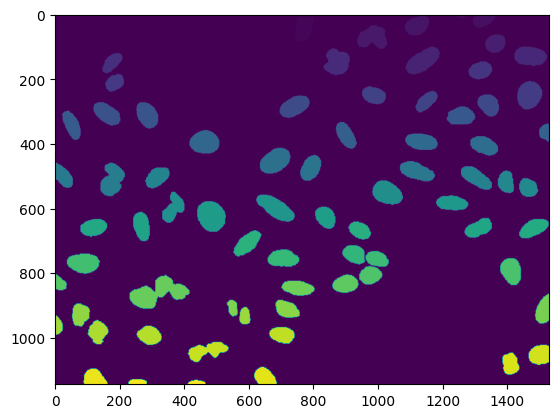

In [100]:
im = skimage.io.imread('/scr/yren/datasets/BBBC039_cleaned_rescaled/masks/IXMtest_P24_s9_w13AC6C03C-E8D7-4A23-B649-514BB4052F52.nuclei-clean.tif')
# plt.imshow(im)
print(np.unique(im)) # indeed

# Remove touch between BBBC039 nuclei and micronuclei in ground truth

- change nuclei.tif suffix to nuclei-clean.tif

In [5]:
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'

masks = os.listdir(mask_save_path)
mask_files = [mask for mask in masks if not mask.startswith('.')]

mic_masks = [mask for mask in mask_files if mask.endswith('phenotype_outlines.png')]
nuc_masks = [mask for mask in mask_files if mask.endswith('nuclei.tif')]

micron_files = [mask_save_path + x for x in mic_masks]
nuclei_files = [mask_save_path + x for x in nuc_masks]

print(micron_files[0])
print(nuclei_files[0])

/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png
/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif


In [6]:
total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m)
    nuc_masks = skimage.io.imread(n)

    # Find overlaps and remove them
    overlap = np.logical_and(mic_masks, nuc_masks)
    print("Overlap:",np.sum(overlap))
    
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16")

    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)

IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif
Overlap: 0
IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.nuclei.tif
Overlap: 0
IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662F57AC25.nuclei.tif
Overlap: 0
IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F75808E2321.nuclei.tif
Overlap: 0
IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27990714B.nuclei.tif
Overlap: 0
IXMtest_K17_s5_w1BB3AD9D7-3A85-458C-AB1C-07A816C2C203.nuclei.tif
Overlap: 0
IXMtest_B04_s2_w17C6C7F8D-98F7-422B-92CD-EA61EE813325.nuclei.tif
Overlap: 0
IXMtest_G16_s6_w1C3F175E2-0AF5-401C-AC5C-8E128A237B22.nuclei.tif
Overlap: 0


/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662F57AC25.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F75808E2321.nuclei-clean.tif is a low contrast image


IXMtest_B23_s1_w152C21D3B-75A9-4FF9-839A-23E6CE19AEEC.nuclei.tif
Overlap: 0
IXMtest_O24_s5_w175443699-7C4C-4E5F-9C5F-57A342CC87DE.nuclei.tif
Overlap: 0
IXMtest_M12_s5_w16D817EFA-C3C9-45DB-AC15-61BB143DEC62.nuclei.tif
Overlap: 0
IXMtest_C05_s7_w1F71963FB-8F29-41CB-A5F5-07CB9584BBC5.nuclei.tif
Overlap: 0
IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1.nuclei.tif
Overlap: 0
IXMtest_N12_s9_w1C98EC3CC-2F8E-4761-A21A-EBF14469AD40.nuclei.tif
Overlap: 0
IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB.nuclei.tif
Overlap: 0
IXMtest_H18_s7_w1D78A9181-AF11-4219-9C1E-2DB2684E948E.nuclei.tif
Overlap: 0


/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_B23_s1_w152C21D3B-75A9-4FF9-839A-23E6CE19AEEC.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_O24_s5_w175443699-7C4C-4E5F-9C5F-57A342CC87DE.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_M12_s5_w16D817EFA-C3C9-45DB-AC15-61BB143DEC62.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_C05_s7_w1F71963FB-8F29-41CB-A5F5-07CB9584BBC5.nuclei-clean.tif is a low contrast image


IXMtest_G10_s3_w1C1257E17-1DBA-4619-B06E-D6DBB8A53088.nuclei.tif
Overlap: 0
IXMtest_E05_s2_w15CCE97F8-3F02-412E-8BF2-FC92972DDA1A.nuclei.tif
Overlap: 0
IXMtest_F08_s1_w144C3056F-C4DD-4D39-A40F-4F4576A6DBD8.nuclei.tif
Overlap: 0
IXMtest_I04_s9_w16A5CC270-8B92-42EE-AA4A-855776F7D46B.nuclei.tif
Overlap: 0
IXMtest_D04_s9_w17B6268DB-8215-4DC6-943C-CC009A8A5732.nuclei.tif
Overlap: 0
IXMtest_C19_s4_w1AD3DC23E-B9B5-46E9-9716-26096C672A13.nuclei.tif
Overlap: 0
IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD.nuclei.tif
Overlap: 0
IXMtest_A09_s1_w1CE70AD49-290D-4312-82E6-CDC717F32637.nuclei.tif
Overlap: 0


...

/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_J07_s9_w16921AB3C-1E9C-41C5-ADDA-7DE5CBF9CCBB.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_B21_s7_w1276972A2-1794-4A98-8E76-876A597C346B.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_M20_s3_w15C73A7C7-F81B-4583-AB8F-0A64336AF070.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_F08_s7_w117D78658-1BA7-495D-9EAA-E4FA155861AC.nuclei-clean.tif is a low contrast image


IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-022806CF6D42.nuclei.tif
Overlap: 0
IXMtest_A21_s1_w1D8BF2790-C628-4109-94AF-DF6D8A3480B6.nuclei.tif
Overlap: 0
IXMtest_E08_s2_w1588EDEBA-1BBA-4E49-810F-2EF2064C8846.nuclei.tif
Overlap: 0
IXMtest_P10_s2_w130B9EBAE-801C-4AAC-A3CE-1C96EE2E6FF9.nuclei.tif
Overlap: 0
IXMtest_G12_s6_w16850371E-A405-4D73-9816-F5F68F885D38.nuclei.tif
Overlap: 0
IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D.nuclei.tif
Overlap: 0
IXMtest_K03_s5_w1DC4CE558-042C-482E-8CAE-FCCB57AA9A55.nuclei.tif
Overlap: 0
IXMtest_G18_s9_w17F495AF2-03D2-4683-BD37-56887F4A3A84.nuclei.tif
Overlap: 0


/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-022806CF6D42.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_A21_s1_w1D8BF2790-C628-4109-94AF-DF6D8A3480B6.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_E08_s2_w1588EDEBA-1BBA-4E49-810F-2EF2064C8846.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_P10_s2_w130B9EBAE-801C-4AAC-A3CE-1C96EE2E6FF9.nuclei-clean.tif is a low contrast image


IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75.nuclei.tif
Overlap: 0
IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2CEA6BE2.nuclei.tif
Overlap: 0
IXMtest_I18_s3_w1544C8B7A-E092-4F9D-B8D3-C489638D770F.nuclei.tif
Overlap: 0
IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC35BAE513.nuclei.tif
Overlap: 0
IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.nuclei.tif
Overlap: 0
IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B61FF39F7.nuclei.tif
Overlap: 0
IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A58471A333A.nuclei.tif
Overlap: 0


/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2CEA6BE2.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I18_s3_w1544C8B7A-E092-4F9D-B8D3-C489638D770F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_4180907/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC35BAE513.nuclei-clean.tif is a low contrast image


- check number of files

In [7]:
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
image_save_path = '/scr/yren/BBBC039_cleaned_rescaled/images/'

masks = os.listdir(mask_save_path)
images = os.listdir(image_save_path)

mask_files = [mask for mask in masks if not mask.startswith('.')]
image_files = [image for image in images if not image.startswith('.')]

inputs = [image for image in image_files if image.endswith('phenotype.tif')]
nuc_masks = [mask for mask in mask_files if mask.endswith('nuclei-clean.tif')]
mic_masks = [mask for mask in mask_files if mask.endswith('phenotype_outlines.png')]

print(len(inputs), len(nuc_masks), len(mic_masks))

127 127 127


- check dimensions

In [8]:
im = skimage.io.imread(image_save_path + inputs[0])
nuc = skimage.io.imread(mask_save_path + nuc_masks[0])
mic = skimage.io.imread(mask_save_path + mic_masks[0])

print(im.shape)
print(nuc.shape)
print(mic.shape)

(1144, 1531)
(1144, 1531)
(1144, 1531)


## Check every image in masks folder if there is any overlap

In [9]:
path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]
mic_files = [file for file in files if file.endswith('.phenotype_outlines.png')]
nuc_files = [file.replace('.phenotype_outlines.png', '.nuclei-clean.tif') for file in mic_files]
for m,n in zip(mic_files, nuc_files):
    mic_masks = skimage.io.imread(path + m) # here is for mnfinder data
    nuc_masks = skimage.io.imread(path + n)

    overlap = np.logical_and(mic_masks, nuc_masks)
    
    if (True in np.unique(overlap)):
        print('Overlaps found!')
    else:
        print('Overlaps not found!')

Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!


# Process mnfinder validation data

- reformat data

In [10]:
from tqdm import tqdm

- remove overlap

In [37]:
im = skimage.io.imread('/scr/yren/mnfinder_new_test_data/2022-05-26_RPE1-2198.phenotype_outlines.png')
im2 = skimage.io.imread('/scr/yren/mnfinder_new_test_data/2022-05-26_RPE1-2198.nuclei.tif')
print(im.shape)
print(im2.shape)

(768, 869, 4)
(768, 869, 4)


# Create metadata file

In [17]:
all_data = pd.DataFrame(columns=['filenames', 'datasets', 'magnification', 'micron'])
# dataset choice: pilot, screen, v3_RPE, v3_HeLa, BBBC039, mnfinder_train, mnfinder_test, mnfinder_validation
# for v3_RPE, v3_HeLa, 1 image for train,val,test respectively.
data_folders = ['dataset_v2', 'dataset_v3', 'BBBC039_cleaned_rescaled', 'mnfinder_clean_data']
screen_imids = ['C2-20X_c0-DAPI-GFP_A1_Tile-17', 
                'C2-20X_c0-DAPI-GFP_A1_Tile-5', 
                'C2-20X_c0-DAPI-GFP_A2_Tile-5', 
                'C2-20X_c0-DAPI-GFP_A3_Tile-6', 
                'C2-20X_c0-DAPI-GFP_B1_Tile-8', 
                'C2-20X_c0-DAPI-GFP_B2_Tile-20',
                'C2-20X_c0-DAPI-GFP_B3_Tile-10', 
                'C2-20X_c0-DAPI-GFP_B3_Tile-16']
all_data
path = '/scr/yren/all_data_micronuclei/'


for folder in data_folders:
    if folder == 'dataset_v2':
        files = os.listdir(path + folder + '/')
        files = [file for file in files if not file.startswith('.')]
        files = [file for file in files if file.endswith('.phenotype.tif')]
        for image in files:
            imid = image.split('.')[0].strip()
            imid = str(imid)
            if (imid in screen_imids):
                row = {'filenames':image, 'datasets':'screen', 'magnification':14, 'micron':4.25}
            else:
                row = {'filenames':image, 'datasets':'pilot', 'magnification':14, 'micron':4.25}
            all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
        
    if folder == 'dataset_v3':
        subfolders = ['HeLa', 'RPE1']
        for subfolder in subfolders:
            if subfolder == 'RPE1':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':subfolder, 'magnification':20, 'micron':6.5}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            else:
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':subfolder, 'magnification':20, 'micron':6.5}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
    if folder == 'mnfinder_clean_data':
        subfolders = ['training', 'testing', 'validation']
        # remeber to check 40x in the testing subfolder
        for subfolder in subfolders:
            if subfolder == 'testing':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    if '40x' in image:
                        row = {'filenames':image, 'datasets':'mnfinder_test', 'magnification':40, 'micron':13}
                        all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
                    else:
                        row = {'filenames':image, 'datasets':'mnfinder_test', 'magnification':20, 'micron':11}
                        all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            elif subfolder == 'training':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':'mnfinder_train', 'magnification':20, 'micron':11}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            elif subfolder == 'validation':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':'mnfinder_validation', 'magnification':20, 'micron':11}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
                
    if folder == 'BBBC039_cleaned_rescaled':
        files = os.listdir(path + folder + '/images/')
        files = [file for file in files if not file.startswith('.')]
        files = [file for file in files if file.endswith('.phenotype.tif')]
        for image in files:
            row = {'filenames':image, 'datasets':'BBBC039', 'magnification':20, 'micron':13.1}
            all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)

/tmp/ipykernel_4180907/427518444.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)


- stratified sampling, and assign train/validation/test as last column (for each datasets)

In [18]:
# all_data[all_data['datasets'] == 'mnfinder_test']
all_data

,filenames,datasets,magnification,micron
0,20X_c0-DAPI_A1_Tile-190.phenotype.tif,pilot,14,4.25
1,C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif,screen,14,4.25
2,C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif,screen,14,4.25
3,C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype.tif,screen,14,4.25
4,20X_c0-DAPI_A1_Tile-50.phenotype.tif,pilot,14,4.25
...,...,...,...,...
195,2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s47.phen...,mnfinder_test,20,11.00
196,2022-10-14_U2OS-4.phenotype.tif,mnfinder_test,20,11.00
197,2022-05-26_RPE1-2198.phenotype.tif,mnfinder_validation,20,11.00
198,2022-10-14_U2OS-1.phenotype.tif,mnfinder_validation,20,11.00


In [19]:
np.unique(all_data.datasets)

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype=object)

- assign set to v3 and mnfinder data

In [20]:
# data_without_mnfinder_v3 = all_data[all_data['datasets'].isin(['pilot', 'screen', 'BBBC039'])]
data_v3 = all_data[all_data['datasets'].isin(['HeLa', 'RPE1'])]
data_mnfinder = all_data[~all_data['datasets'].isin(['pilot', 'screen', 'BBBC039', 'HeLa', 'RPE1'])]
data_mnfinder['split'] = data_mnfinder['datasets'].apply(lambda x: x.split('_')[-1])

/tmp/ipykernel_4180907/2647424196.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_mnfinder['split'] = data_mnfinder['datasets'].apply(lambda x: x.split('_')[-1])


In [21]:
data_v3

,filenames,datasets,magnification,micron
18,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5
19,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5
20,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5
21,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5
22,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5
23,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5


In [22]:
split = ['train', 'validation', 'test'] * 2
data_v3['split'] = split
data_v3

/tmp/ipykernel_4180907/1814804534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_v3['split'] = split


,filenames,datasets,magnification,micron,split
18,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
19,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
20,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
21,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
22,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
23,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


In [23]:
data_mnfinder.head()

,filenames,datasets,magnification,micron,split
151,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
152,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
153,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
154,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
155,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train


## Stratified sampling for pilot & screen

In [24]:
from sklearn.model_selection import train_test_split

pilot_screen = all_data[all_data['datasets'].isin(['pilot', 'screen'])]
X_train, X_tmp = train_test_split(pilot_screen, test_size=0.3, stratify=pilot_screen['datasets'])

In [25]:
X_test, X_validation = train_test_split(X_tmp, test_size=0.5, stratify=X_tmp['datasets'])

In [26]:
print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(12, 4)
(3, 4)
(3, 4)


In [27]:
X_train['split'] = 'train'
X_validation['split'] = 'validation'
X_test['split'] = 'test'

### create split for BBBBC039 data

In [28]:
with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/training.txt', 'r') as file:
    lines = file.readlines()
training = [line.strip().split('.')[0] for line in lines]

with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/validation.txt', 'r') as file:
    lines = file.readlines()
validation = [line.strip().split('.')[0] for line in lines]

with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/test.txt', 'r') as file:
    lines = file.readlines()
test = [line.strip().split('.')[0] for line in lines]


In [29]:
data_bbbc039 = all_data[all_data.datasets == 'BBBC039']
data_bbbc039['split'] = 'none'

# Convert lists to sets for efficient lookup
training_set = set(training)
validation_set = set(validation)
test_set = set(test)

# Assign 'split' values using vectorized operations
data_bbbc039['split'] = data_bbbc039['filenames'].apply(lambda x: 
    'train' if x.split('.')[0] in training_set else 
    'validation' if x.split('.')[0] in validation_set else 
    'test' if x.split('.')[0] in test_set else 
    'none'
)

/tmp/ipykernel_4180907/1159607307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bbbc039['split'] = 'none'
/tmp/ipykernel_4180907/1159607307.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bbbc039['split'] = data_bbbc039['filenames'].apply(lambda x:


In [30]:
data_bbbc039

,filenames,datasets,magnification,micron,split
24,IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108D...,BBBC039,20,13.1,test
25,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,BBBC039,20,13.1,validation
26,IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662...,BBBC039,20,13.1,test
27,IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F758...,BBBC039,20,13.1,validation
28,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,BBBC039,20,13.1,train
...,...,...,...,...,...
146,IXMtest_I18_s3_w1544C8B7A-E092-4F9D-B8D3-C4896...,BBBC039,20,13.1,validation
147,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,20,13.1,train
148,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,20,13.1,train
149,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,20,13.1,train


In [32]:
# data_without_v2_039
final_data = pd.concat([data_v3, X_train, X_validation, X_test, data_mnfinder, data_bbbc039], ignore_index=True)

In [35]:
print(final_data.shape)
np.unique(final_data.datasets)

(200, 5)


array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype=object)

In [36]:
print(final_data[final_data.split == 'train'].shape)
print(final_data[final_data.split == 'validation'].shape)
print(final_data[final_data.split == 'test'].shape)

(103, 5)
(40, 5)
(57, 5)


In [112]:
final_data[final_data.split=='test'].shape

(57, 5)

In [107]:
final_data.to_csv('/scr/yren/all_data_micronuclei/metadata.csv', index=False)

# Process dataset v2 and v3 (HeLa, RPE1), v3 has been scaled already in scale_aligned_dataset_v2_v3

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy
from tqdm import tqdm
import time

import torch
import matplotlib.pyplot as plt

In [2]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
data_v2_v3 = metadata[metadata['datasets'].isin(['pilot', 'screen', 'HeLa', 'RPE1'])]
data_v2_v3

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.50,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.50,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.50,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.50,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.50,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.50,test
6,C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype.tif,screen,14,4.25,train
7,C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif,screen,14,4.25,train
8,20X_c0-DAPI_A1_Tile-170.phenotype.tif,pilot,14,4.25,train
9,20X_c0-DAPI_A1_Tile-70.phenotype.tif,pilot,14,4.25,train


In [123]:
(14/4.25)/(20/6.5)

1.0705882352941176

In [4]:

metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
data_v2_v3 = metadata[metadata['datasets'].isin(['pilot', 'screen', 'HeLa', 'RPE1'])]
print(data_v2_v3.shape)

for row in range(data_v2_v3.shape[0]):
    if data_v2_v3.iloc[row]['datasets'] == 'HeLa':
        path = '/scr/yren/all_data_micronuclei/dataset_v3/HeLa/'
    elif data_v2_v3.iloc[row]['datasets'] == 'RPE1':
        path = '/scr/yren/all_data_micronuclei/dataset_v3/RPE1/'
    else: # pilot/screen
        path = '/scr/yren/all_data_micronuclei/dataset_v2/'
        
    # convert mask and save
    imid = data_v2_v3.iloc[row]['filenames'].split('.')[0]
    im = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    edge = im[:,:,0] > 0
    mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
    mask = mask + edge # micronuclei mask, boolean
    # print(np.unique(mask))
    
    if data_v2_v3.iloc[row]['split'] == 'train':
        save_path = '/scr/yren/all_data_micronuclei/train/'
    elif data_v2_v3.iloc[row]['split'] == 'validation':
        save_path = '/scr/yren/all_data_micronuclei/validation/'
    elif data_v2_v3.iloc[row]['split'] == 'test':
        save_path = '/scr/yren/all_data_micronuclei/test/'
    
    nuclei_mask = skimage.io.imread(path + imid + '.nuclei-clean.tif')
    nuclei_mask = nuclei_mask > 0
    phenotype = skimage.io.imread(path + imid + '.phenotype.tif')
    
    if data_v2_v3.iloc[row]['datasets'] in ['HeLa', 'RPE1']:
        scale = round((14/4.25)/(data_v2_v3.iloc[row]['magnification']/data_v2_v3.iloc[row]['micron']), 1)
        # print(scale)
        mask = skimage.transform.rescale(mask, scale=scale)
        nuclei_mask = skimage.transform.rescale(nuclei_mask, scale=scale)
        phenotype = skimage.transform.rescale(phenotype, scale=scale)
    
    
    labels = skimage.morphology.label(mask)
    labels = np.asarray(labels, dtype='uint16')
    
    nuc_labels = skimage.morphology.label(nuclei_mask)
    nuc_labels = np.asarray(nuc_labels, dtype='uint16')
    # print(phenotype.shape)
    # print(len(np.unique(nuc_labels)))
 
    # save masks
    skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
    skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuc_labels)
    skimage.io.imsave(save_path + imid + '.phenotype.tif', phenotype)

    
   

(24, 5)


/tmp/ipykernel_8587/2598891429.py:49: UserWarning: /scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
/tmp/ipykernel_8587/2598891429.py:50: UserWarning: /scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuc_labels)
/tmp/ipykernel_8587/2598891429.py:49: UserWarning: /scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
/tmp/ipykernel_8587/2598891429.py:50: UserWarning: /scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuc_labels)
/tmp/ipykernel_8587/2598891429.py:49: UserWarning: /scr/yren/all_data_micronuclei/test/C

In [7]:
metadata[metadata.datasets == 'HeLa']

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test


(2992, 2992) (2992, 2992) (2992, 2992)


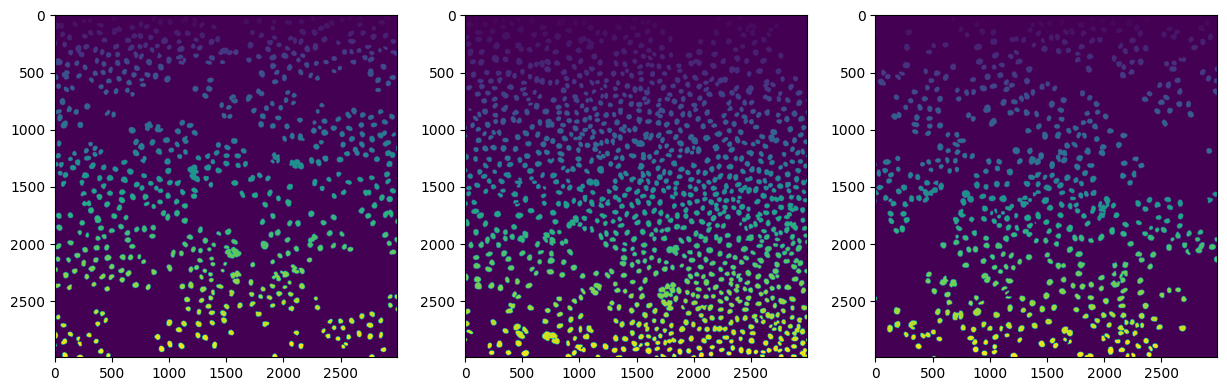

In [9]:
fig, ax = plt.subplots(1,3, figsize=(15,15))
path = '/scr/yren/all_data_micronuclei/'
im1 = skimage.io.imread(path + 'train/' + 'C1-20X_c0_B3_Tile-5.nuclei-clean.tif')
im2 = skimage.io.imread(path + 'validation/' + 'C1-20X_c0_B3_Tile-24.nuclei-clean.tif')
im3 = skimage.io.imread(path + 'test/' + 'C1-20X_c0_B3_Tile-15.nuclei-clean.tif')
print(im1.shape, im2.shape, im3.shape)


ax[0].imshow(im1)
ax[1].imshow(im2)
ax[2].imshow(im3)

In [8]:
metadata[metadata.datasets == 'RPE1']

,filenames,datasets,magnification,micron,split
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
5,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


(2992, 2992) (2992, 2992) (2992, 2992)


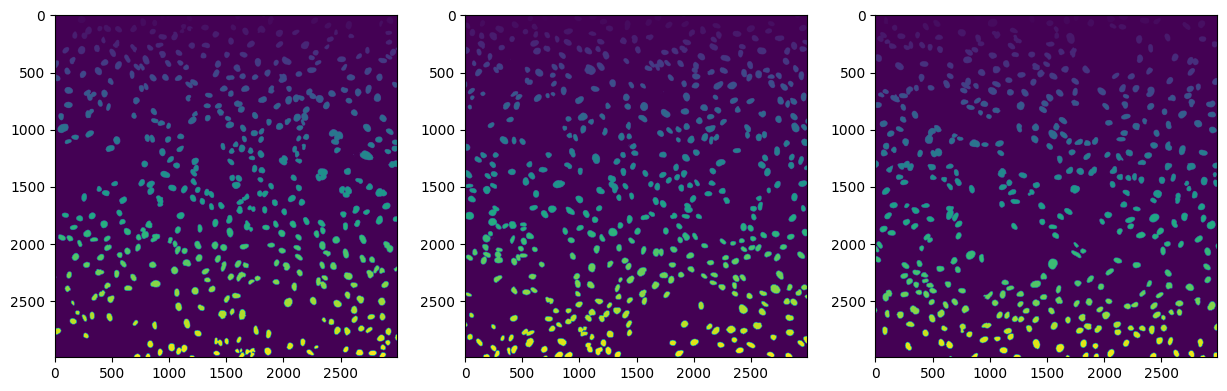

In [6]:
fig, ax = plt.subplots(1,3, figsize=(15,15))
path = '/scr/yren/all_data_micronuclei/'
im1 = skimage.io.imread(path + 'train/' + 'C1-20X_c0_phalloidin_C3_Tile-18.nuclei-clean.tif')
im2 = skimage.io.imread(path + 'validation/' + 'C1-20X_c0_phalloidin_C3_Tile-15.nuclei-clean.tif')
im3 = skimage.io.imread(path + 'test/' + 'C1-20X_c0_phalloidin_C3_Tile-44.nuclei-clean.tif')
print(im1.shape, im2.shape, im3.shape)


ax[0].imshow(im1)
ax[1].imshow(im2)
ax[2].imshow(im3)

In [55]:
data_v2_v3[data_v2_v3['split']=='train'].shape

(14, 5)

(2720, 2720)
(2992, 2992)


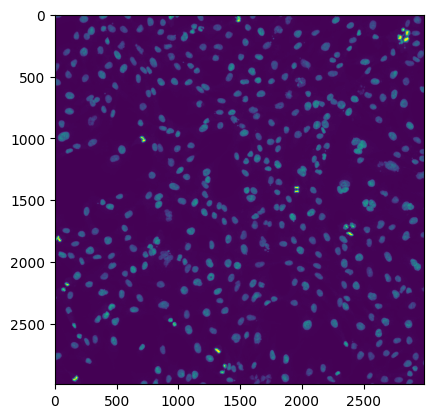

In [10]:
origin = skimage.io.imread('/scr/yren/all_data_micronuclei/dataset_v3/RPE1/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif')
im = skimage.io.imread('/scr/yren/all_data_micronuclei/train/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif')
print(origin.shape)
print(im.shape)
plt.imshow(im)

# Process MNFinder Train/Val/Test data

In [41]:
np.unique(metadata['datasets'])

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype=object)

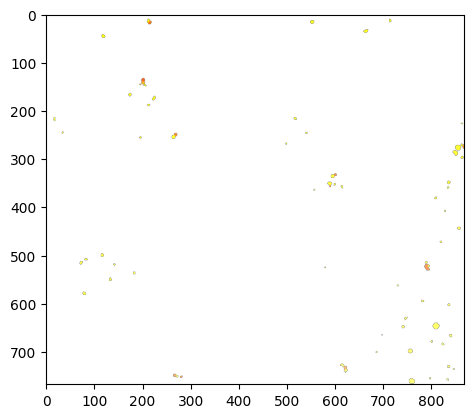

In [42]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/mnfinder_clean_data/validation/2022-10-14_U2OS-1.phenotype_outlines.png')
im2 = np.mean(im, axis=2) > 0
plt.imshow(im)

In [30]:
(14/4.25)/(40/13)

1.0705882352941176

In [12]:
data_mnfinder = metadata[metadata['datasets'].isin(['mnfinder_train', 'mnfinder_validation', 'mnfinder_test'])]

for row in range(data_mnfinder.shape[0]):
    # rescale input, nuclei & micronuclei masks
    scale = round((14/4.25)/(data_mnfinder.iloc[row]['magnification']/data_mnfinder.iloc[row]['micron']), 1)
    # print(scale)
    
    if data_mnfinder.iloc[row]['split'] == 'train':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/training/'
        save_path = '/scr/yren/all_data_micronuclei/train/'
    elif data_mnfinder.iloc[row]['split'] == 'validation':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/validation/'
        save_path = '/scr/yren/all_data_micronuclei/validation/'
    elif data_mnfinder.iloc[row]['split'] == 'test':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/testing/'
        save_path = '/scr/yren/all_data_micronuclei/test/'
    
    imid = data_mnfinder.iloc[row]['filenames'].split('.')[0]
    
    # process micronuclei mask
    micro_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    micro_mask = np.mean(micro_mask, axis=2) > 0
    micro_mask = skimage.transform.rescale(micro_mask, scale=scale)
    # convert to labeled matrix
    micro_labels = skimage.morphology.label(micro_mask)
    micro_labels = np.asarray(micro_labels, dtype='uint16')
    skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
    
    # process nuclei mask
    nuclei_mask = skimage.io.imread(path + imid + '.nuclei-clean.tif')
    nuclei_mask = nuclei_mask > 0 # convert to boolean
    nuclei_mask = skimage.transform.rescale(nuclei_mask, scale=scale)
    # convert to labeled matrix
    nuclei_labels = skimage.morphology.label(nuclei_mask)
    nuclei_labels = np.asarray(nuclei_labels, dtype='uint16')
    skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
    
    # process input images
    input = skimage.io.imread(path + imid + '.phenotype.tif')
    input = skimage.transform.rescale(input, scale=scale)
    skimage.io.imsave(save_path + imid + '.phenotype.tif', input)
    # print(input.shape)

/tmp/ipykernel_8587/66308229.py:27: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.phenotype_outlines.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
/tmp/ipykernel_8587/66308229.py:27: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
/tmp/ipykernel_8587/66308229.py:36: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.nuclei-clean.tif is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
/tmp/ipykernel_8587/66308229.py:27: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-1.phenotype_outlin

In [44]:
sub = metadata[~metadata['datasets'].isin(['BBBC039'])]
sub = sub[sub['split'].isin(['test'])]
sub.shape

(21, 5)

# Read and Resave, BBBC039_clean data has been rescaled (dont use shutil, will corrupt data)

In [13]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/masks/IXMtest_P24_s9_w13AC6C03C-E8D7-4A23-B649-514BB4052F52.phenotype_outlines.png')
print(im.shape)
# plt.imshow(im)

(1144, 1531)


In [14]:
metadata.shape

(200, 5)

In [15]:
metadata[metadata['split']=='train'].shape

(103, 5)

In [16]:
data_bbbc039 = metadata[metadata['datasets'].isin(['BBBC039'])]
data_bbbc039

for row in range(0, data_bbbc039.shape[0]):
    imid = data_bbbc039.iloc[row]['filenames'].split('.')[0]
    image_path = '/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/images/'
    mask_path = '/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/masks/'
    
    im_src = image_path + imid + '.phenotype.tif'
    im_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.phenotype.tif'

    nuclei_src =  mask_path + imid + '.nuclei-clean.tif'
    nuclei_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.nuclei-clean.tif'
    
    micron_src =  mask_path + imid + '.phenotype_outlines.png'
    micron_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.phenotype_outlines.png'
    
    im = skimage.io.imread(im_src)
    skimage.io.imsave(im_dst, im)
    
    nuclei_mask = skimage.io.imread(nuclei_src)
    skimage.io.imsave(nuclei_dst, nuclei_mask)
    
    micron_mask = skimage.io.imread(micron_src)
    skimage.io.imsave(micron_dst, micron_mask)
    

/tmp/ipykernel_8587/1024847520.py:19: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype.tif is a low contrast image
  skimage.io.imsave(im_dst, im)
/tmp/ipykernel_8587/1024847520.py:22: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(nuclei_dst, nuclei_mask)
/tmp/ipykernel_8587/1024847520.py:25: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(micron_dst, micron_mask)
/tmp/ipykernel_8587/1024847520.py:19: UserWarning: /scr/yren/all_data_micronuclei/validation/IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.phenotype.tif is a low contrast image
  skimage.io.imsave(im_dst, im)
/tmp/ipykernel_8587/1024847520.py:22: UserWarning: /scr/yren/all_data_micronuclei/validation/IXMtest_N12_s7_w166

## Check number of objects in nuclei mask & if it is labled matrix

In [17]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
path = '/scr/yren/all_data_micronuclei/'
for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    nuclei_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.nuclei-clean.tif'
    nuclei_mask = skimage.io.imread(nuclei_mask_path)
    
    nuclei_labels = skimage.morphology.label(nuclei_mask)
    print(imid, len(np.unique(nuclei_labels)))
        

C1-20X_c0_B3_Tile-5 630
C1-20X_c0_B3_Tile-24 1099
C1-20X_c0_B3_Tile-15 562
C1-20X_c0_phalloidin_C3_Tile-18 438
C1-20X_c0_phalloidin_C3_Tile-15 494
C1-20X_c0_phalloidin_C3_Tile-44 423
C2-20X_c0-DAPI-GFP_A3_Tile-6 1320
C2-20X_c0-DAPI-GFP_A1_Tile-17 1240
20X_c0-DAPI_A1_Tile-170 1259
20X_c0-DAPI_A1_Tile-70 468
20X_c0-DAPI_A1_Tile-10 651
20X_c0-DAPI_A1_Tile-90 906
20X_c0-DAPI_A1_Tile-110 646
C2-20X_c0-DAPI-GFP_B3_Tile-10 1737
C2-20X_c0-DAPI-GFP_B2_Tile-20 1391
C2-20X_c0-DAPI-GFP_B1_Tile-8 985
20X_c0-DAPI_A1_Tile-190 743
20X_c0-DAPI_A1_Tile-30 469
20X_c0-DAPI_A1_Tile-50 1364
C2-20X_c0-DAPI-GFP_B3_Tile-16 1441
C2-20X_c0-DAPI-GFP_A2_Tile-5 1425
C2-20X_c0-DAPI-GFP_A1_Tile-5 1213
20X_c0-DAPI_A1_Tile-150 793
20X_c0-DAPI_A1_Tile-130 1819
2022-05-27_RPE1-3 108
2022-05-27_RPE1-1 83
2022-05-27_RPE1-2197 62
2022-03-18_RPE1-3 136
2022-03-18_RPE1-5 123
2022-03-18_RPE1-4 97
2022-05-26_RPE1-2 75
2022-05-26_RPE1-1 76
2023-05-31_misc-10 31
2023-05-31_misc-11 37
2023-05-31_misc-8 26
2023-05-31_misc-9 32
2023

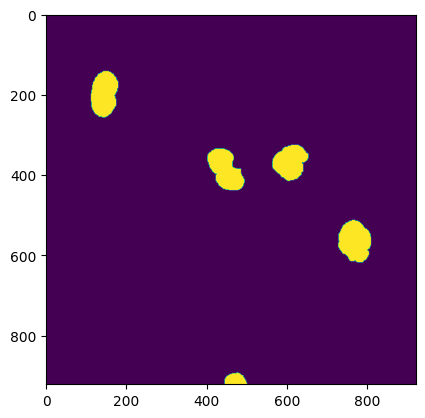

In [19]:
# the one that only has 6 objects
im = skimage.io.imread(path + 'train/' + '2023-05-31_misc-2.nuclei-clean.tif')
plt.imshow(im)

## Check number of objects in micronuclei mask & if it is labeled matrix

In [20]:
path = '/scr/yren/all_data_micronuclei/'
for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    micron_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.phenotype_outlines.png'
    micron_mask = skimage.io.imread(micron_mask_path)
    
    micron_labels = skimage.morphology.label(micron_mask)
    print(imid, len(np.unique(micron_labels)))

C1-20X_c0_B3_Tile-5 70
C1-20X_c0_B3_Tile-24 143
C1-20X_c0_B3_Tile-15 116
C1-20X_c0_phalloidin_C3_Tile-18 84
C1-20X_c0_phalloidin_C3_Tile-15 79
C1-20X_c0_phalloidin_C3_Tile-44 61
C2-20X_c0-DAPI-GFP_A3_Tile-6 97
C2-20X_c0-DAPI-GFP_A1_Tile-17 80
20X_c0-DAPI_A1_Tile-170 138
20X_c0-DAPI_A1_Tile-70 66
20X_c0-DAPI_A1_Tile-10 84
20X_c0-DAPI_A1_Tile-90 110
20X_c0-DAPI_A1_Tile-110 45
C2-20X_c0-DAPI-GFP_B3_Tile-10 138
C2-20X_c0-DAPI-GFP_B2_Tile-20 88
C2-20X_c0-DAPI-GFP_B1_Tile-8 65
20X_c0-DAPI_A1_Tile-190 76
20X_c0-DAPI_A1_Tile-30 49
20X_c0-DAPI_A1_Tile-50 164
C2-20X_c0-DAPI-GFP_B3_Tile-16 101
C2-20X_c0-DAPI-GFP_A2_Tile-5 84
C2-20X_c0-DAPI-GFP_A1_Tile-5 84
20X_c0-DAPI_A1_Tile-150 53
20X_c0-DAPI_A1_Tile-130 188
2022-05-27_RPE1-3 91
2022-05-27_RPE1-1 74
2022-05-27_RPE1-2197 64
2022-03-18_RPE1-3 106
2022-03-18_RPE1-5 82
2022-03-18_RPE1-4 58
2022-05-26_RPE1-2 70
2022-05-26_RPE1-1 83
2023-05-31_misc-10 10
2023-05-31_misc-11 26
2023-05-31_misc-8 11
2023-05-31_misc-9 15
2023-05-31_misc-3 5
2023-05-31_mi

(922, 922)


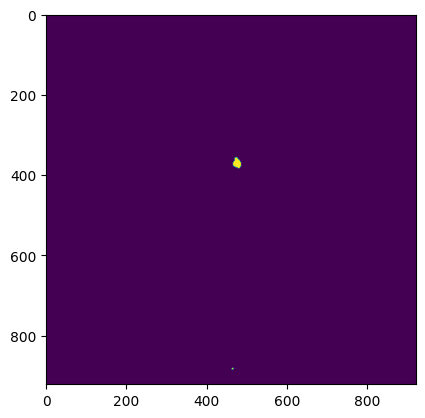

In [23]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/train/2023-05-31_misc-2.phenotype_outlines.png') # 3 objects
print(im.shape)
plt.imshow(im)

# Create 3 histograms of micronuclei areas, colored per dataset among three splits

In [24]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy

import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
split = ['train', 'validation', 'test']
path = '/scr/yren/all_data_micronuclei/'
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
print(metadata.shape)

(200, 5)


In [30]:
metadata.head()

,filenames,datasets,magnification,micron,split
0,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
1,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
2,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
3,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
4,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train


- create a new df for each folder

In [25]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
train_set = metadata[metadata.split == 'train']
path = '/scr/yren/all_data_micronuclei/train/'

for row in range(train_set.shape[0]):
    imid = train_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':train_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)

In [26]:
df_areas.to_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv', index=False)

In [27]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv')
df_areas

,image_id,area,dataset
0,C1-20X_c0_B3_Tile-5,17,HeLa
1,C1-20X_c0_B3_Tile-5,68,HeLa
2,C1-20X_c0_B3_Tile-5,29,HeLa
3,C1-20X_c0_B3_Tile-5,51,HeLa
4,C1-20X_c0_B3_Tile-5,14,HeLa
...,...,...,...
3434,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,161,BBBC039
3435,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,56,BBBC039
3436,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,101,BBBC039
3437,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,64,BBBC039


In [28]:
df_areas[df_areas.area==1789]

,image_id,area,dataset


- Train

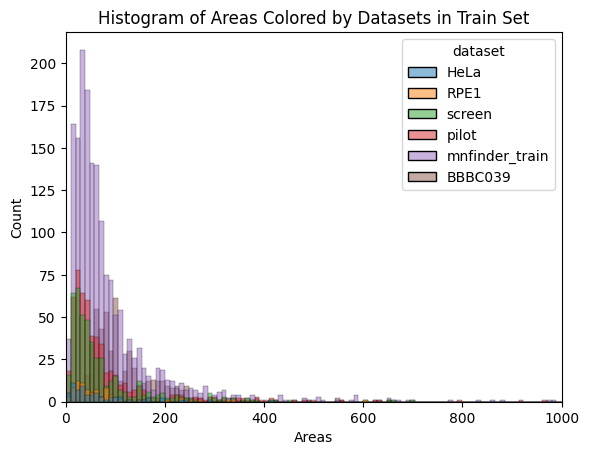

In [29]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,1000])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Train Set')
plt.show()

In [30]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
validation_set = metadata[metadata.split == 'validation']
path = '/scr/yren/all_data_micronuclei/validation/'

for row in range(validation_set.shape[0]):
    imid = validation_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':validation_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)
df_areas.to_csv('/scr/yren/all_data_micronuclei/validation_area_distribution.csv', index=False)

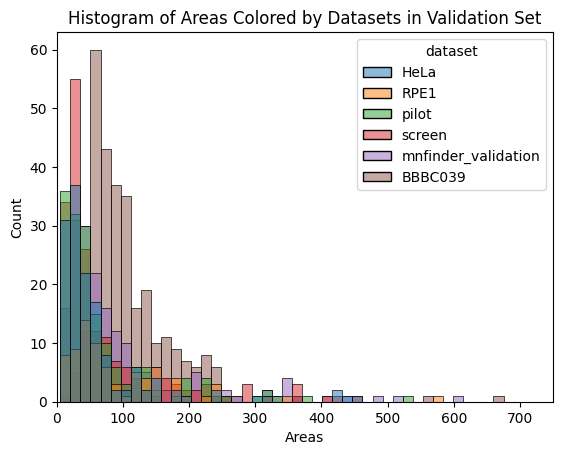

In [31]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/validation_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,750])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Validation Set')
plt.show()

In [32]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
test_set = metadata[metadata.split == 'test']
path = '/scr/yren/all_data_micronuclei/test/'

for row in range(test_set.shape[0]):
    imid = test_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':test_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)
df_areas.to_csv('/scr/yren/all_data_micronuclei/test_area_distribution.csv', index=False)

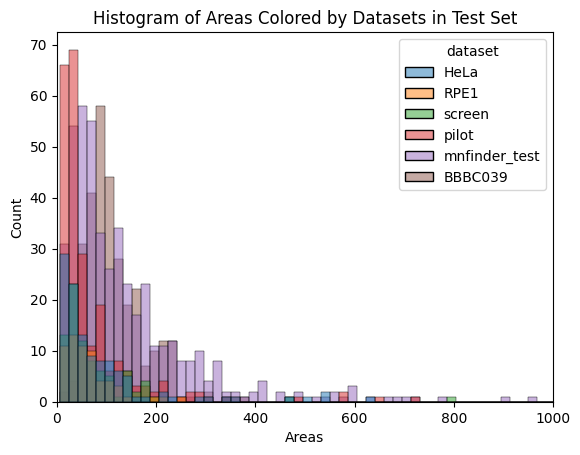

In [33]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/test_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,1000])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Test Set')
plt.show()

# Visually verify the nuclei mask

In [1]:
import skimage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [2]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
print(metadata.shape)

(265, 5)


IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BDDB27076 BBBC039 (1144, 1531)


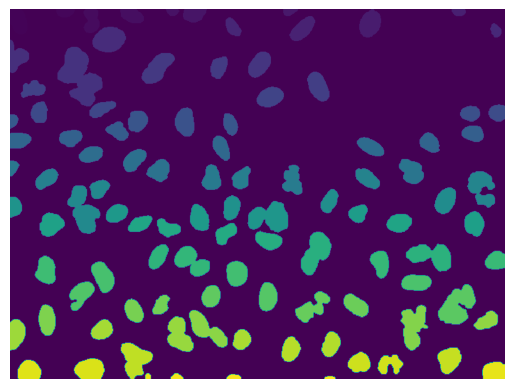

In [3]:
path = '/scr/yren/all_data_micronuclei/'

for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    nuclei_mask = skimage.io.imread(path + metadata.iloc[row]['split'] + '/' + imid + '.nuclei-clean.tif')
    print(imid, metadata.iloc[row]['datasets'], nuclei_mask.shape)
    
    # optimize for not crashing notebook
    plt.imshow(nuclei_mask)
    plt.axis('off')
    plt.show()
    plt.close('all')
    clear_output(wait=True)
    time.sleep(1)

# Visually verify the micronnuclei mask

IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BDDB27076 BBBC039 (1144, 1531)


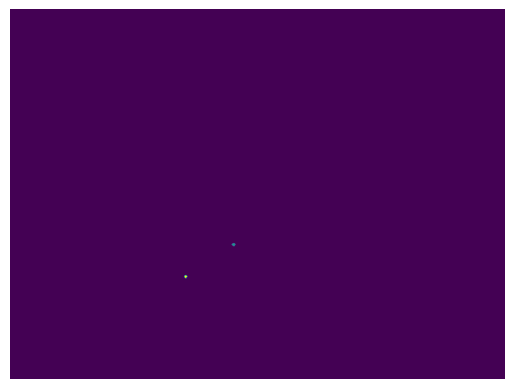

In [5]:
path = '/scr/yren/all_data_micronuclei/'

for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    micron_mask = skimage.io.imread(path + metadata.iloc[row]['split'] + '/' + imid + '.phenotype_outlines.png')
    print(imid, metadata.iloc[row]['datasets'], micron_mask.shape)
    
    # optimize for not crashing notebook
    plt.imshow(micron_mask)
    plt.axis('off')
    plt.show()
    plt.close('all')
    clear_output(wait=True)
    time.sleep(1)